In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings

warnings.simplefilter('ignore')
plt.rcParams['figure.figsize'] = (15, 7)

In this area, we will cover the following recipes:
* Preparing time series data for supervised learning
* One-step forecasting using linear regression models with scikit-learn
* Multi-step forecasting using linear regression models with scikit-learn
* Forecasting using non-linear models with sktime
* Optimizing a forecasting model with hyperparameter tuning
* Forecasting with exogenous variables and ensemble learning

In [2]:
path = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch12')

daily_temp = pd.read_csv(path.joinpath('daily_weather.csv'), index_col='DateTime', parse_dates=True)
daily_temp.columns = ['y']

energy = pd.read_csv(path.joinpath('energy_consumption.csv'), index_col='Month', parse_dates=True)
energy.columns = ['y']

air = pd.read_csv(path.joinpath('air_passenger.csv'), index_col='date', parse_dates=True)
air.columns = ['y']

In [3]:
# Then, add the proper frequency for each DataFrame
daily_temp.index.freq = 'D'
energy.index.freq = 'MS'
air.index.freq = 'M'

<Axes: title={'center': 'Monthly Passengers'}, xlabel='date'>

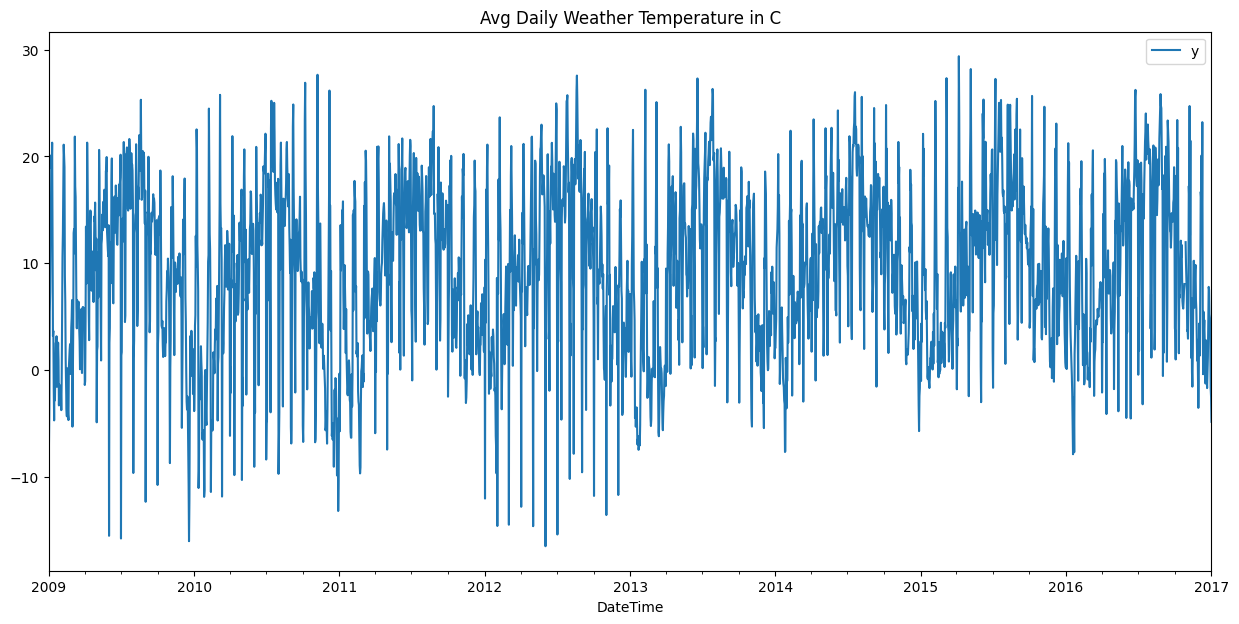

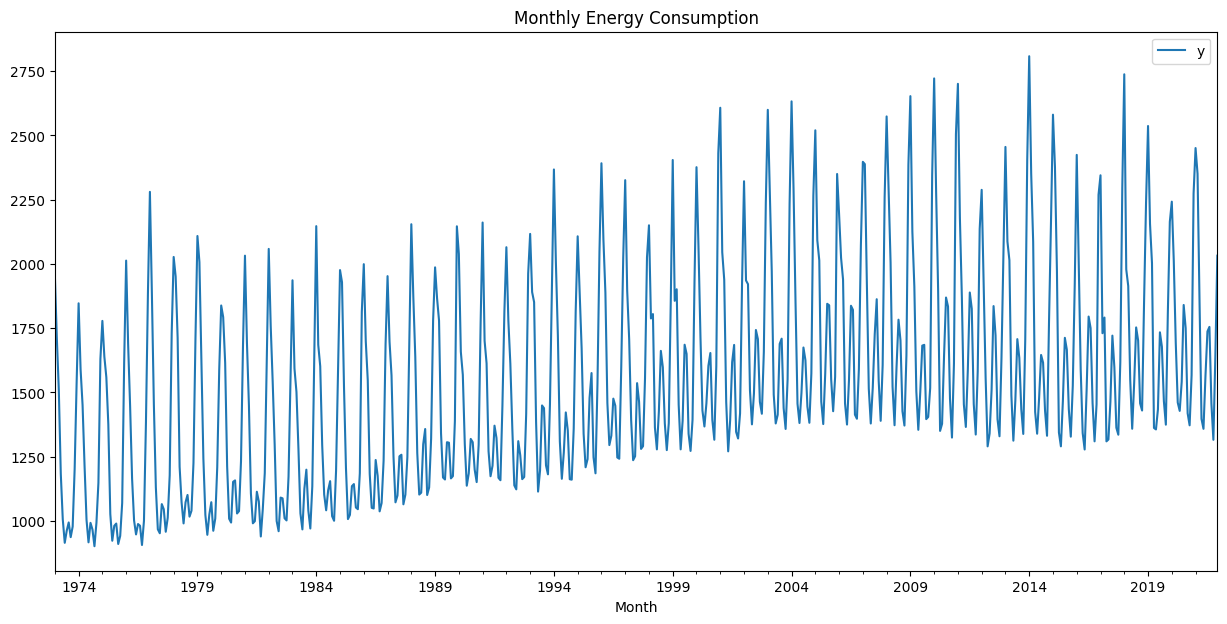

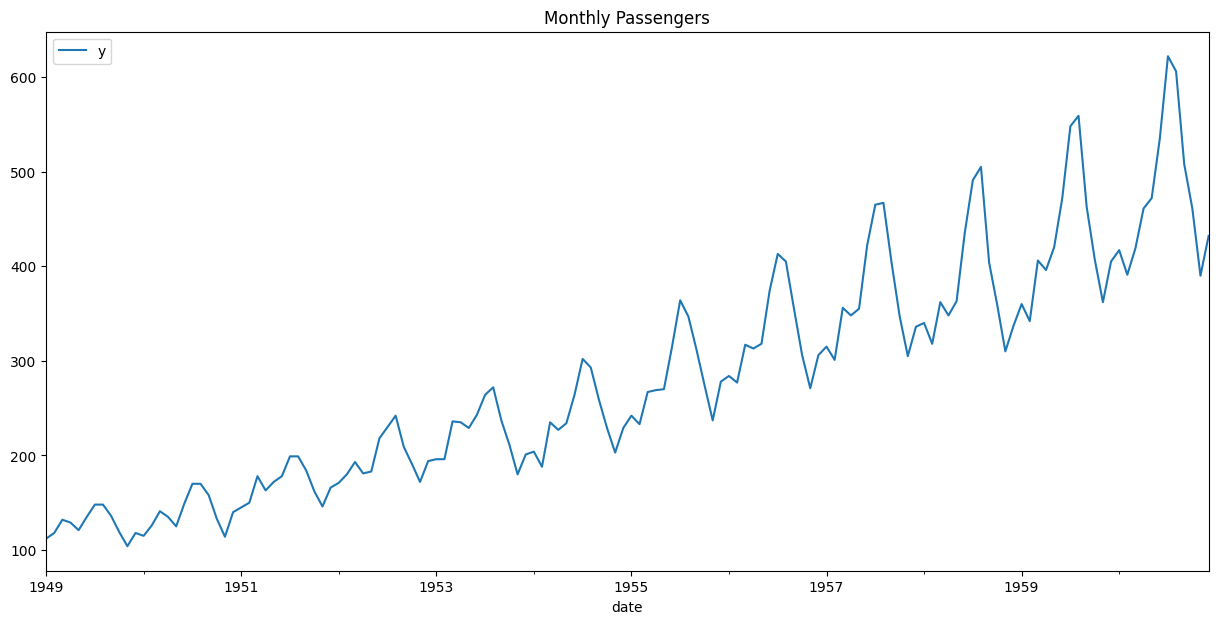

In [61]:
# You can plot the three DataFrames to gain an understanding of how they differ
daily_temp.plot(title='Avg Daily Weather Temperature in C')
energy.plot(title='Monthly Energy Consumption')
air.plot(title='Monthly Passengers')

In [5]:
air_copy = air.copy()
energy_copy = energy.copy()
daily_temp_copy = daily_temp.copy()

In [6]:
def handle_missing_data(df):
    n = int(df.isna().sum())
    if n > 0:
        print(f'found {n} missing observations...')
        df.ffill(inplace=True)

In [7]:
# Pass each DataFrame to the handle_missing_data function
for df in [air_copy, energy_copy, daily_temp_copy]:
    handle_missing_data(df)

found 2 missing observations...


Create the one_step_forecast function, which returns a DataFrame with a specified number of independent variables (columns) and a target variable (column). The total number of columns returned is based on the sliding window parameter (number of columns = sliding window + 1).

In [90]:
def one_step_forecast(df, window):
    '''
    This function forecasts only one step forward

    df: dataframe for forecast
    window: number of steps or observation backward used to forecast one step forward
    '''
    d = df.values
    x = []
    n = len(df)
    idx = df.index[:-window]

    for start in range(n-window):
        end = start + window
        x.append(d[start:end])

    cols = [f'x_{i}' for i in range(1, window+1)]
    x = np.array(x).reshape(n-window, -1)
    y = df.iloc[window:].values
    
    df_xs = pd.DataFrame(x, columns=cols, index=idx)
    df_y = pd.DataFrame(y.reshape(-1), columns=['y'], index=idx)

    return pd.concat([df_y, df_xs], axis=1).dropna()

In [9]:
air_os = one_step_forecast(air_copy, 5)
energy_os = one_step_forecast(energy_copy, 5)
daily_temp_os = one_step_forecast(daily_temp_copy, 5)

In [92]:
def split_data(df, test_split=0.15):
    '''
    This function is used to split a dataframe
    
    df: dataframe to be split
    test_split: proportion of the split size
    '''
    n = int(len(df) * test_split)
    train, test = df[:-n], df[-n:]
    return train, test

In [11]:
train, test = split_data(air_os)
print(f'Train: {len(train)} Test: {len(test)}')

Train: 119 Test: 20


In [12]:
class Standardize:
    def __init__(self, split=0.15):
        self.split = split

    def _transform(self, df):
        return (df - self.mu)/self.sigma
    
    def split_data(self, df):
        n = int(len(df) * self.split)
        train, test = df[:-n], df[-n:]

        return train, test
    
    def fit_transform(self, train, test):
        self.mu = train.mean()
        self.sigma = train.std()
        train_s = self._transform(train)
        test_s = self._transform(test)

        return train_s, test_s
    
    def transform(self, df):
        return self._transform(df)
    
    def inverse(self, df):
        return (df * self.sigma)+self.mu
    
    def inverse_y(self, df):
        return (df * self.sigma[0])+self.mu[0]

In [13]:
scaler = Standardize()
train_s, test_s = scaler.fit_transform(train, test)
train_original = scaler.inverse(train_s)
y_train_original = scaler.inverse_y(train_s['y'])

In [46]:
# The following is an example of engineering date time related features using pandas
df['day_of_week'] = df.index.dayofweek
df['days_in_month'] = df.index.days_in_month
df['month_end'] = df.index.is_month_end.astype(int)
df['is_leap'] = df.index.is_leap_year.astype(int)
df['month'] = df.index.month
df.head()

,y,day_of_week,days_in_month,month_end,is_leap,month
DateTime,,,,,,
2009-01-01,-6.810629,3,31,0,0,1
2009-01-02,-3.360486,4,31,0,0,1
2009-01-03,5.435694,5,31,0,0,1
2009-01-04,7.283889,6,31,0,0,1
2009-01-05,12.690069,0,31,0,0,1


### 2. One-step forecasting using linear regression models with scikit-learn

In [15]:
from sklearn.linear_model import(LinearRegression, ElasticNet, Ridge, Lasso, HuberRegressor)

In [16]:
air_cp = air.copy()
en_cp = energy.copy()
dw_cp = daily_temp.copy()

In [20]:
en_cp.dtypes

y    float64
dtype: object

In [34]:
handle_missing_data(en_cp)
handle_missing_data(air_cp)
handle_missing_data(dw_cp)

found 2 missing observations...


In [67]:
# Use one_step_forecast to convert the time series DataFrames into a supervised learning problem with 10 steps (windows)
en_reg = one_step_forecast(en_cp, 10)
air_reg = one_step_forecast(air_cp, 10)
dw_reg = one_step_forecast(dw_cp, 20)

In [68]:
train_en, test_en = split_data(en_reg, test_split=0.10)
scaler_en = Standardize()
train_en_stnd, test_en_stnd = scaler_en.fit_transform(train_en, test_en)

train_air, test_air = split_data(air_reg, test_split=.10)
scaler_air = Standardize()
train_air_stnd, test_air_stnd = scaler_air.fit_transform(train_air, test_air)

train_dw, test_dw = split_data(dw_reg, test_split=.10)
scaler_dw = Standardize()
train_dw_stnd, test_dw_stnd = scaler_dw.fit_transform(train_dw, test_dw)

In [69]:
from sktime.performance_metrics.forecasting import MeanAbsoluteError, MeanAbsolutePercentageError, MeanAbsoluteScaledError, MeanSquaredError

In [70]:
mse = MeanSquaredError()
mae = MeanAbsoluteError()
mape = MeanAbsolutePercentageError()
mase = MeanAbsoluteScaledError()

Note, you will be calculating RMSE as the square root of MSE, for example, using 
            
            np.sqrt(mse(y_actual – y_hat)).

In [71]:
def train_model(train, test, regressor, reg_name):
    '''
    train: train set,
    test: test set,
    regressor: instances of different regression models
    reg_name: name of the regressor class
    '''
    X_train, y_train = train.drop(columns=['y']), train['y']
    X_test, y_test = test.drop(columns=['y']), test['y']
    print(f'training {reg_name} ...')

    regressor.fit(X_train, y_train)

    yhat = regressor.predict(X_test)
    rmse_test = np.sqrt(mse(y_test, yhat))
    mape_test = mape(y_test, yhat)
    mase_test = mase(y_true=y_test, y_pred=yhat, y_train=y_train)
    mse_test = mse(y_true=y_test, y_pred=yhat)
    residuals = y_test.values - yhat

    model_metadata = {
        'Model Name': reg_name, 
        'Model': regressor,
        'RMSE': rmse_test,
        'MAPE': mape_test,
        'MASE': mase_test,
        'yhat': yhat,
        'resid': residuals,
        'actual': y_test.values
    }

    return model_metadata

In [72]:
regressors = {
    'Linear Regression': LinearRegression(),
    'Elastic Net': ElasticNet(0.5),
    'Ridge Regression': Ridge(0.5),
    'Lasso Regression': Lasso(0.5),
    'Huber Regression': HuberRegressor()
}

In [89]:
def train_different_models(train, test, regressors):
    '''
    train: train test
    test: test set
    regressors: list of different regression models
    '''
    results = []
    for regressor_name, regressor in regressors.items():
        results.append(train_model(train, test, regressor, regressor_name))

    return results

In [74]:
en_results = train_different_models(train_en_stnd, test_en_stnd, regressors)
air_results = train_different_models(train_air_stnd, test_air_stnd, regressors)
dw_results = train_different_models(train_dw_stnd, test_dw_stnd, regressors)

training Linear Regression ...
training Elastic Net ...
training Ridge Regression ...
training Lasso Regression ...


training Huber Regression ...
training Linear Regression ...
training Elastic Net ...
training Ridge Regression ...
training Lasso Regression ...
training Huber Regression ...
training Linear Regression ...
training Elastic Net ...
training Ridge Regression ...
training Lasso Regression ...
training Huber Regression ...


In [75]:
dw_results

[{'Model Name': 'Linear Regression',
  'Model': LinearRegression(),
  'RMSE': 0.6254937347335916,
  'MAPE': 1.157446729673951,
  'MASE': 0.9945564724216335,
  'yhat': array([-0.40273469, -0.4769104 , -0.7451348 , -0.73959933, -0.41176528,
         -0.36162498, -0.31047288, -0.42889922, -0.34701882, -0.23335042,
         -0.08869877,  0.01490758, -0.09225065, -0.22937427, -0.47515456,
         -1.19084362, -0.85881662, -0.61104273,  0.37550923,  0.20882542,
          0.65452862,  0.69337437,  0.64341927,  0.69904396, -0.10392422,
         -0.58853663, -1.24267405, -0.081418  ,  0.33754001,  0.00538719,
          0.44133007, -0.16235631, -0.35782351, -0.2678163 , -0.33643988,
         -0.07551712,  0.1721237 , -0.18836107, -0.85577027, -0.5263294 ,
         -0.44681539, -0.37774834, -0.12147723, -0.03537099, -0.01255882,
         -1.16085591, -0.81168195, -0.33632866,  0.37290281,  0.59055089,
          0.90867581,  0.99473419,  0.54320412,  0.42900477, -0.40235894,
         -0.46419435,

In [76]:
type(dw_results)

list

In [77]:
cols = ['Model Name', 'RMSE', 'MAPE', 'MASE']

dw_results = pd.DataFrame(dw_results)

dw_results[cols].sort_values('MASE')

,Model Name,RMSE,MAPE,MASE
4,Huber Regression,0.640476,1.147118,0.963036
0,Linear Regression,0.625494,1.157447,0.994556
2,Ridge Regression,0.625485,1.157272,0.994569
1,Elastic Net,0.739347,0.925889,1.302249
3,Lasso Regression,0.816070,0.919457,1.469965


In [88]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Evaluate model performance
def plot_results(cols, results, data_name):
    '''
    cols: list of columns names,
    results: list of results
    data_name: name of the data
    '''
    for row in results[cols].iterrows():
        yhat, resid, actual, name = row[1]
        
        plt.title(f'{data_name} - {name}')
        plt.plot(actual, 'k--', alpha=.5)
        plt.plot(yhat, 'k')
        plt.legend(['actual', 'forecast'])
        plot_acf(resid, zero=False, title=f'{data_name} ACF - Autocorrelation')
        plot_pacf(resid, zero=False, title=f'{data_name} PACF - Autocorrelation')
        plt.show()

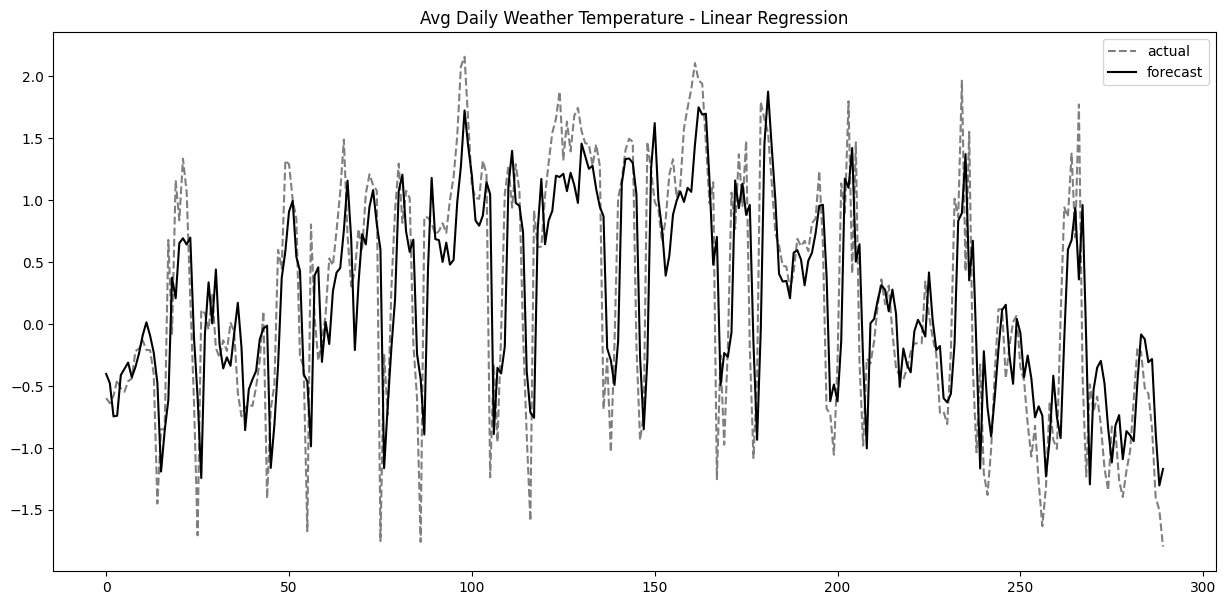

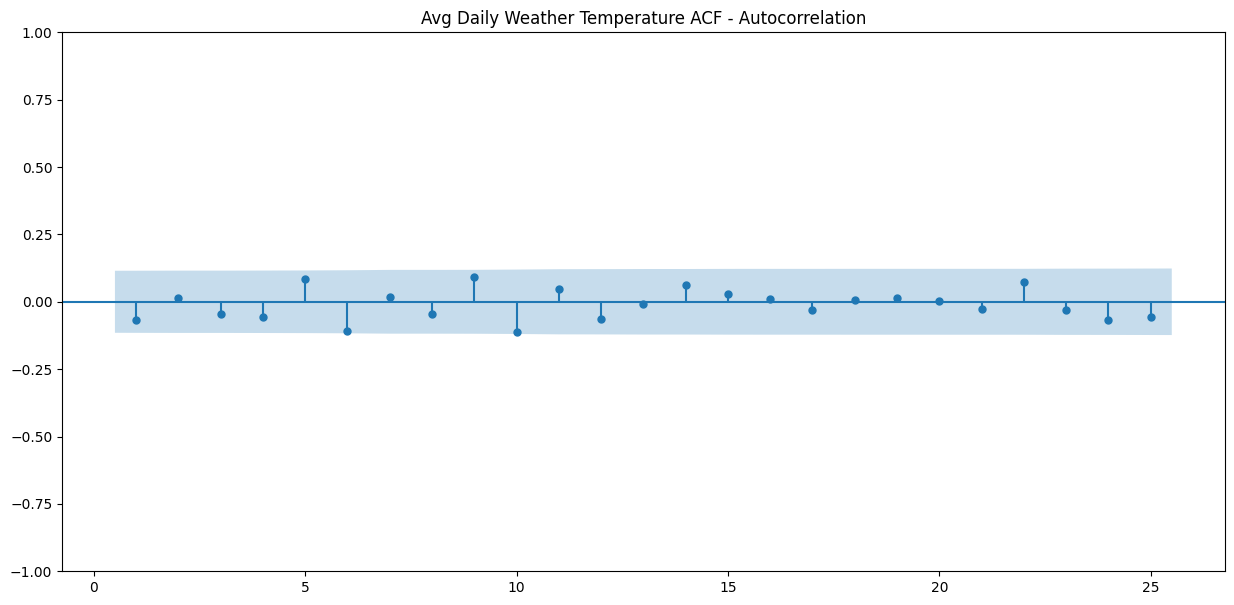

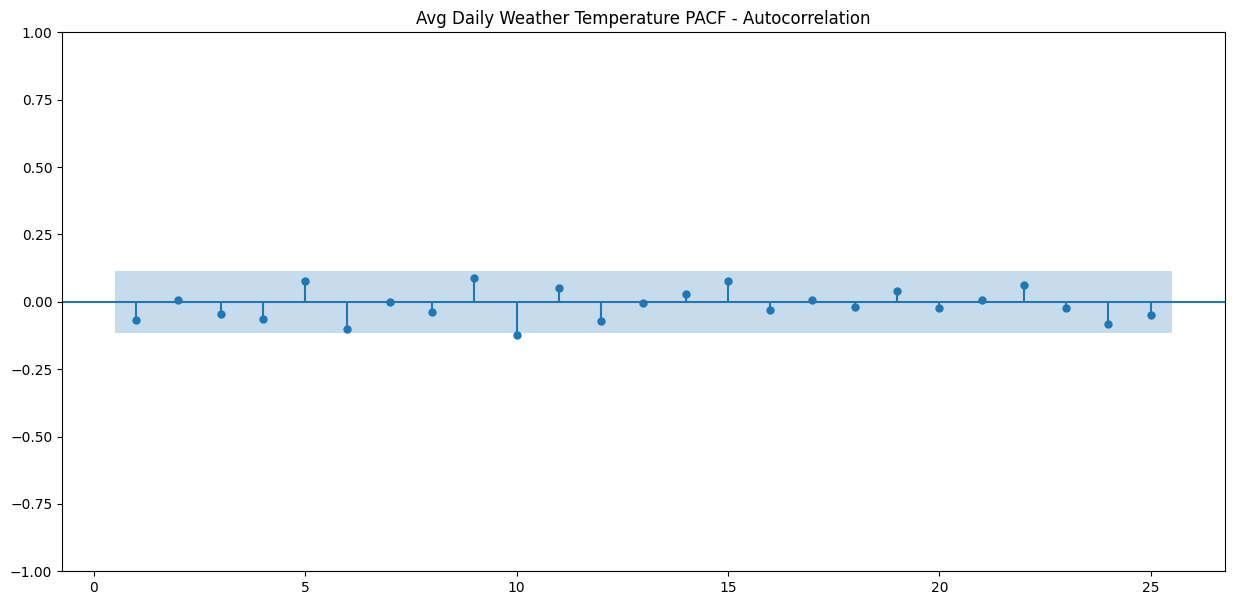

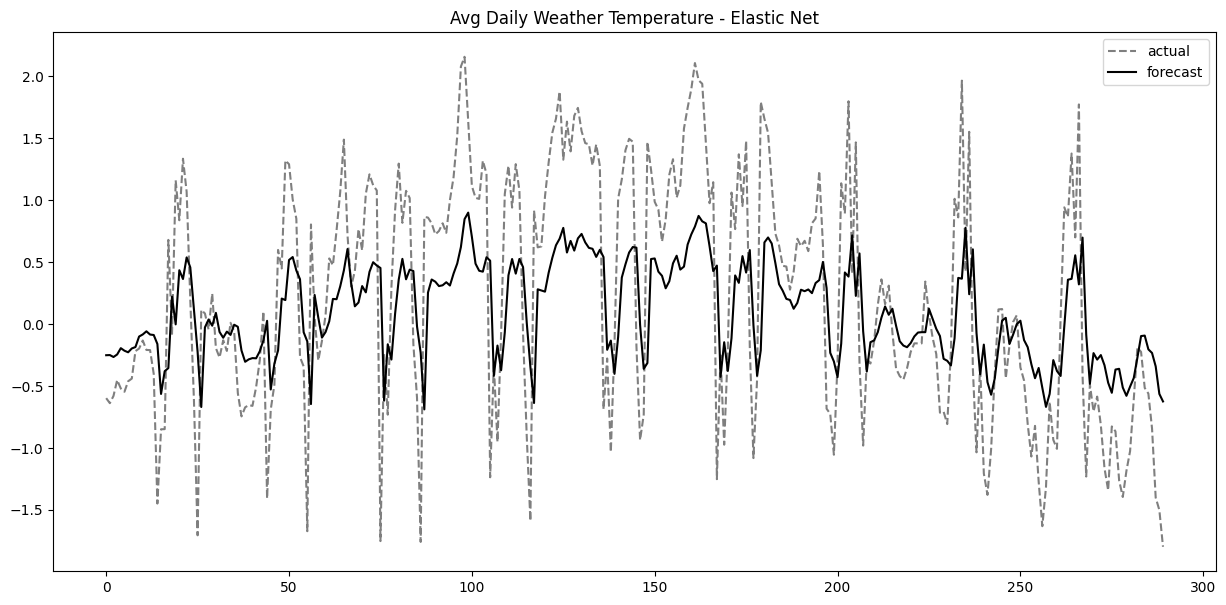

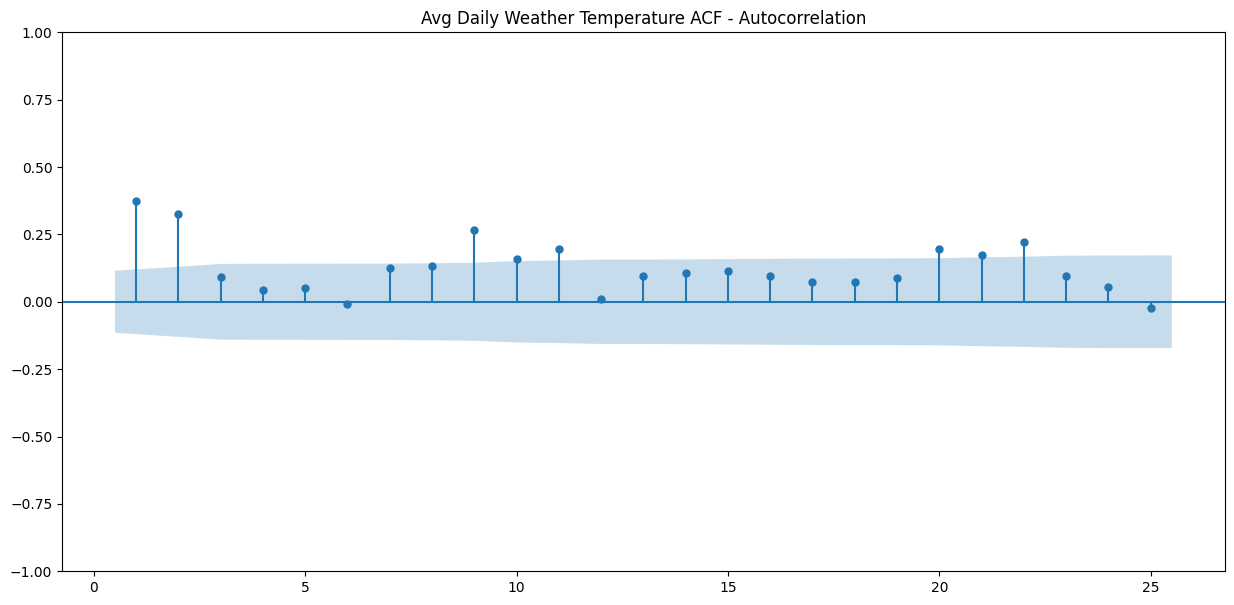

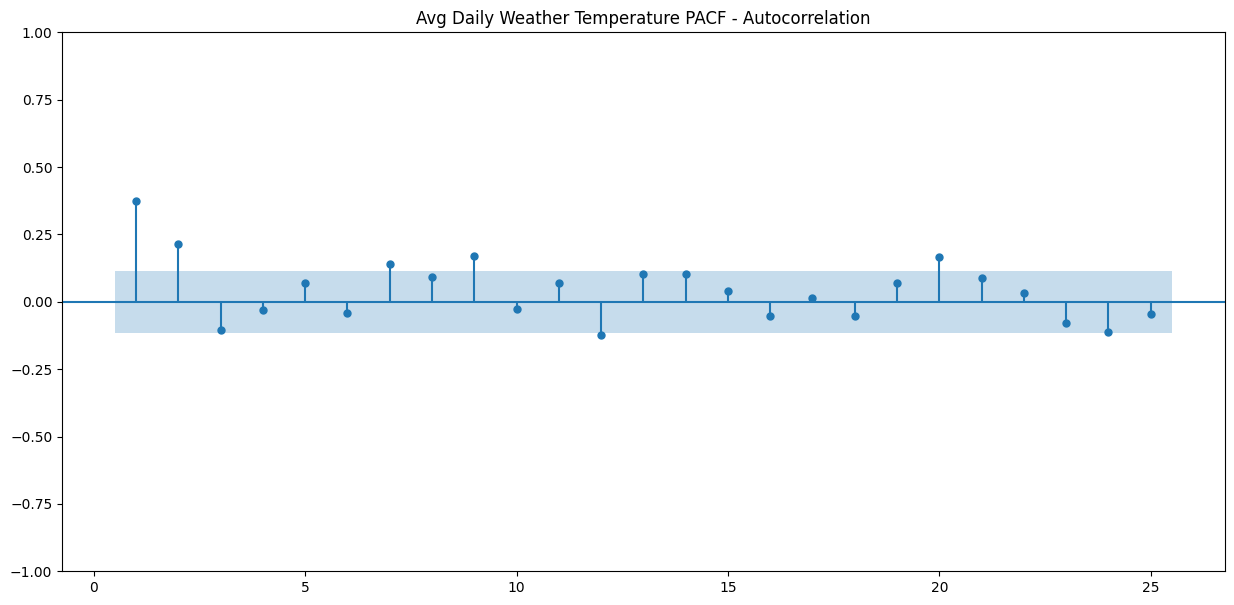

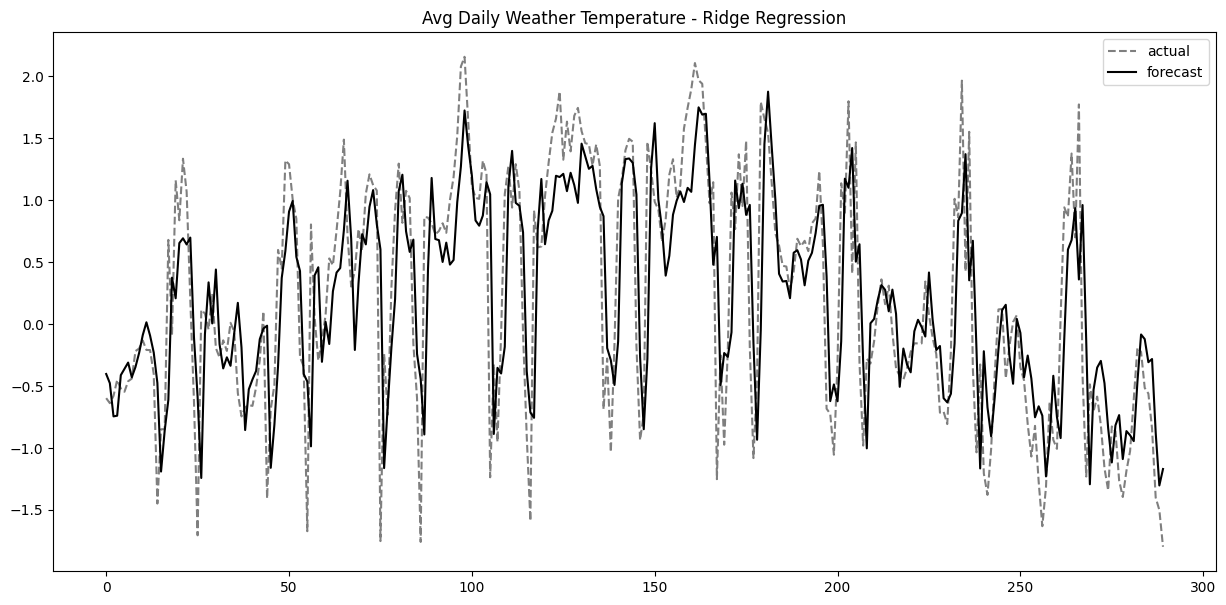

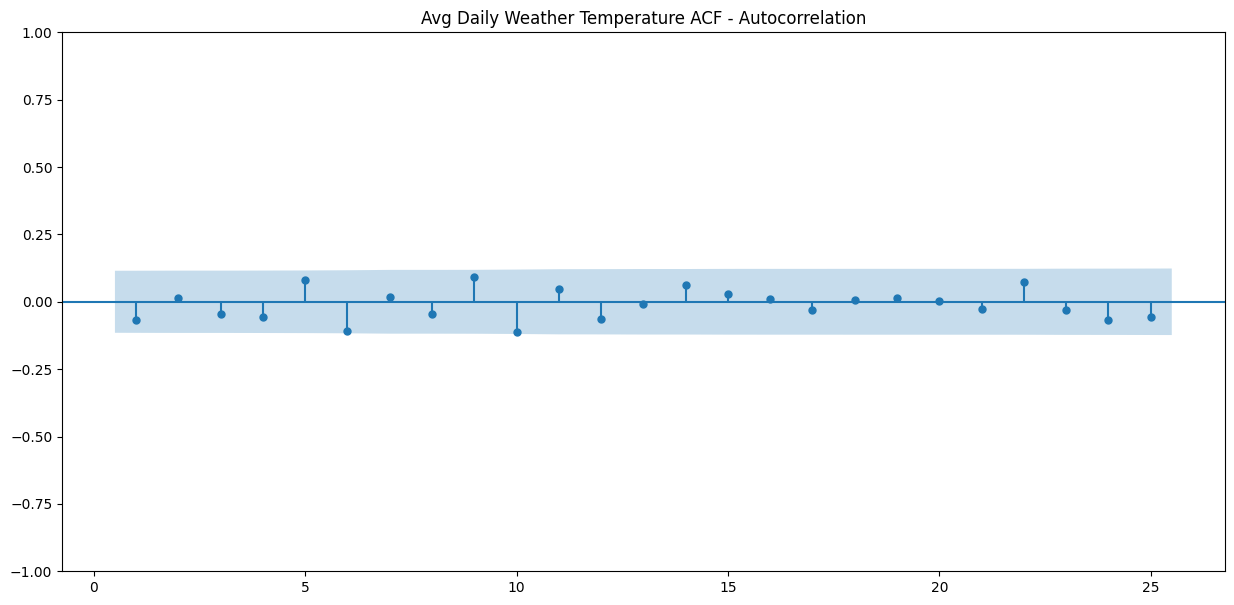

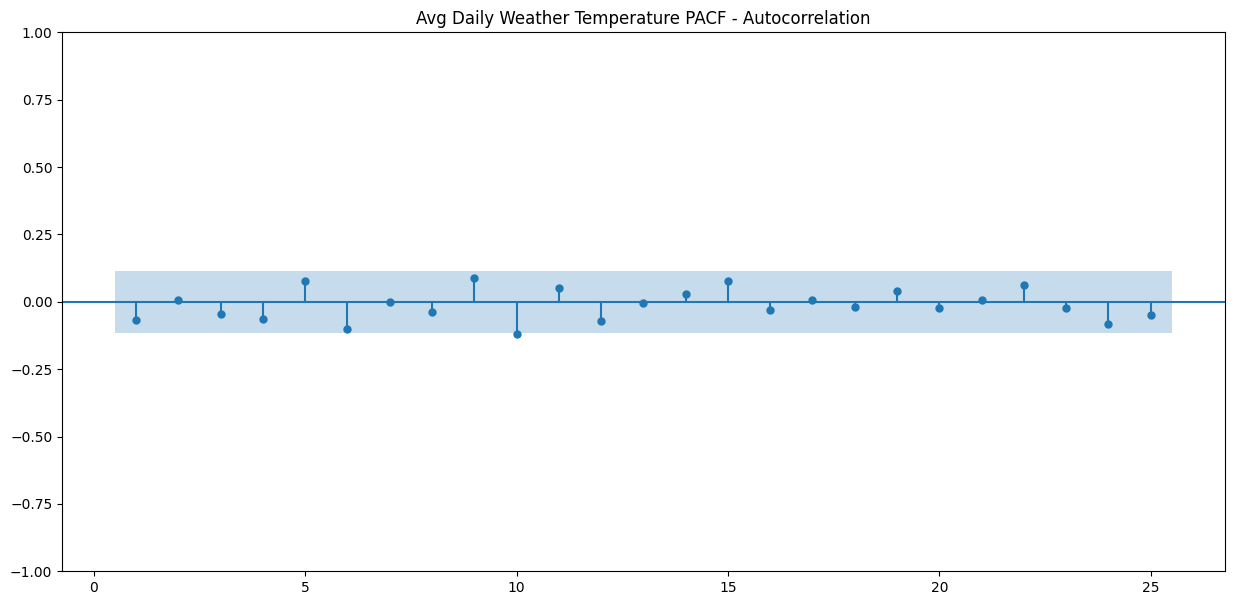

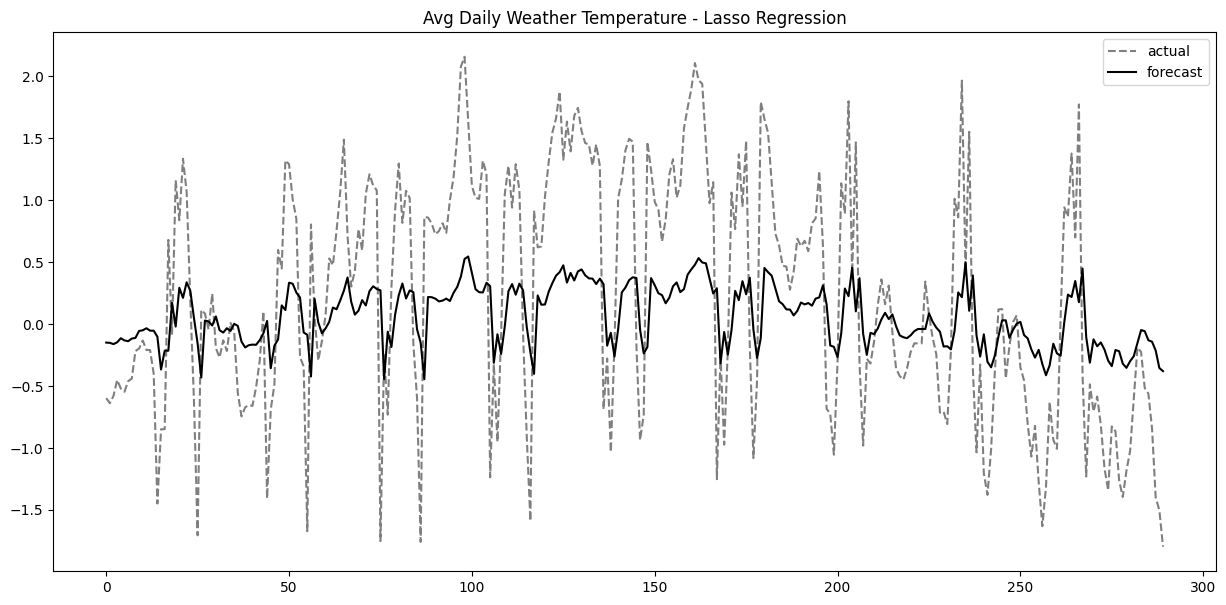

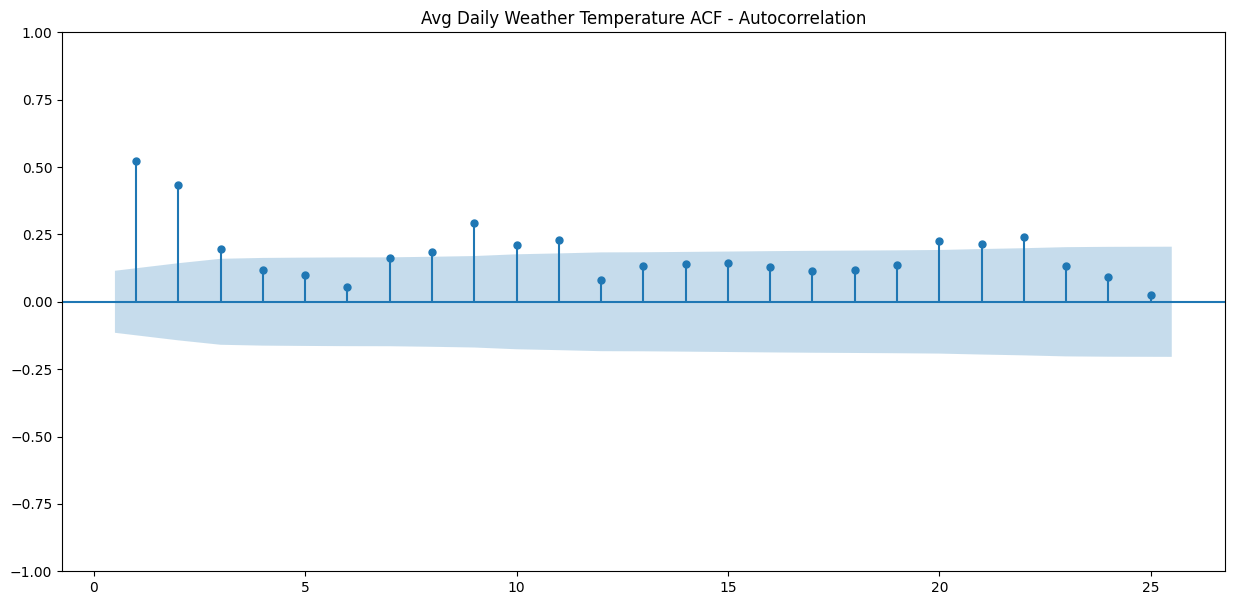

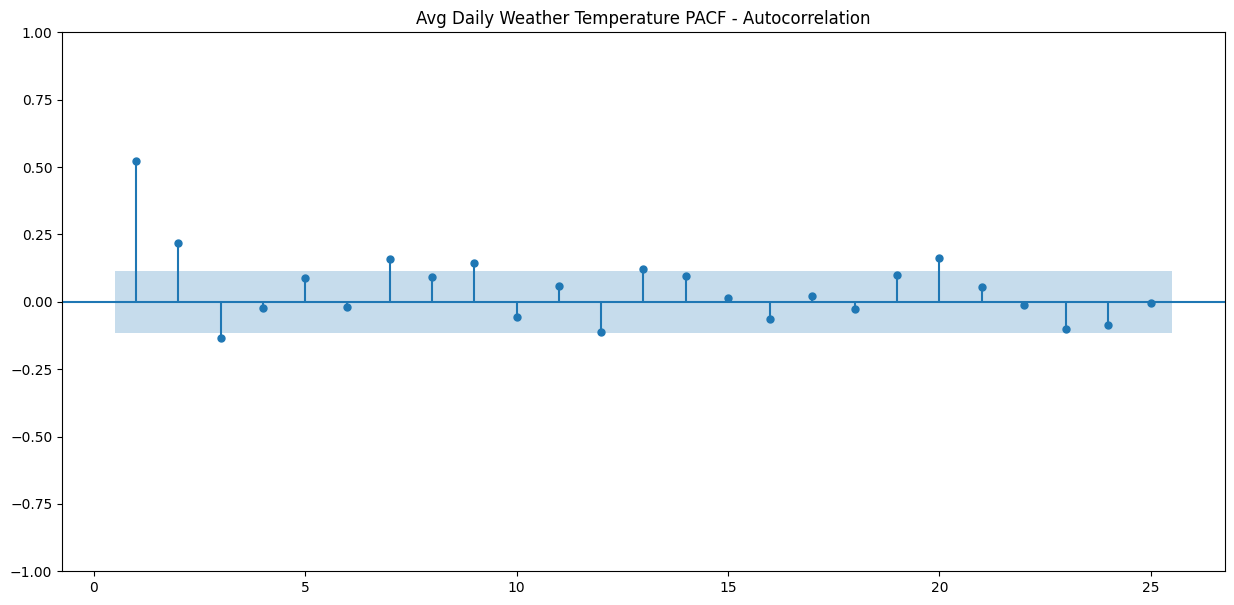

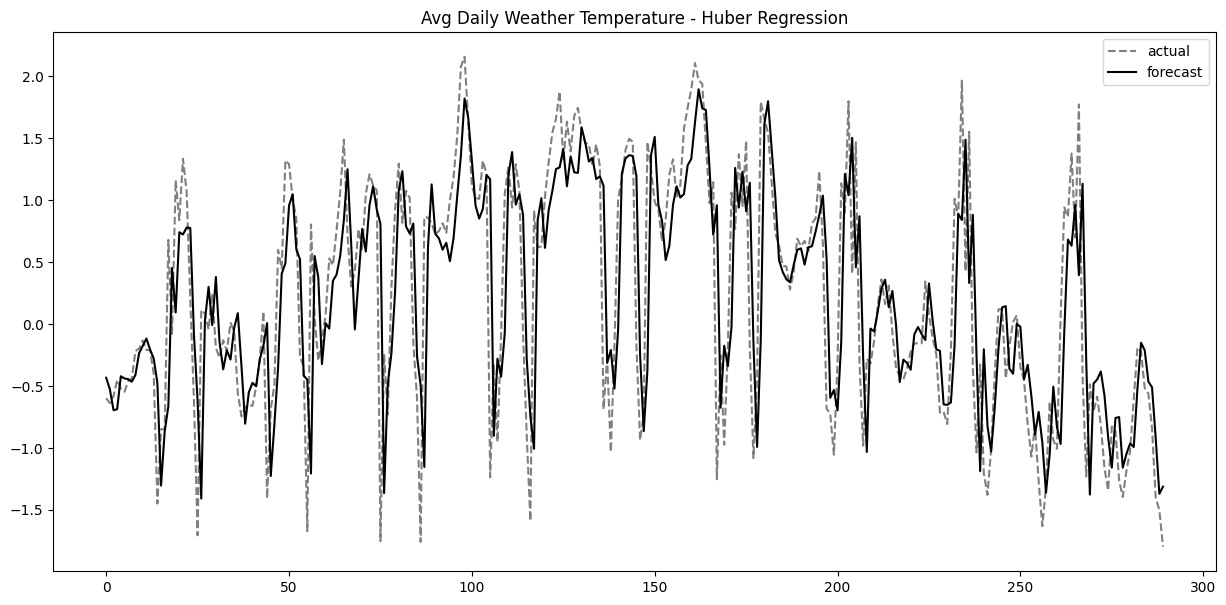

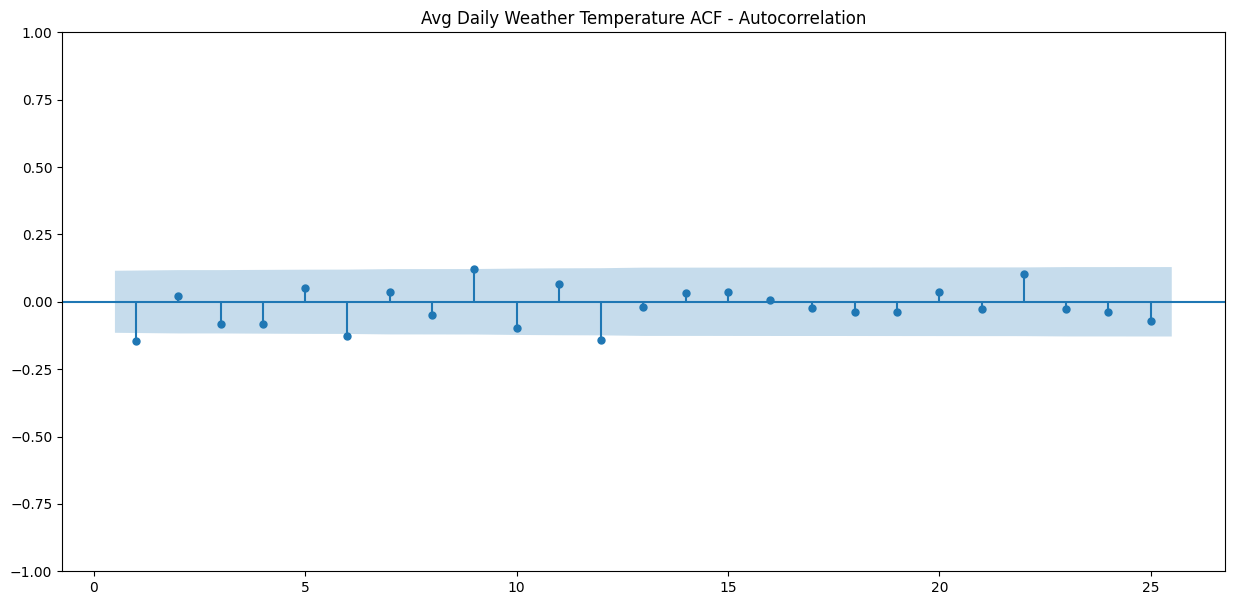

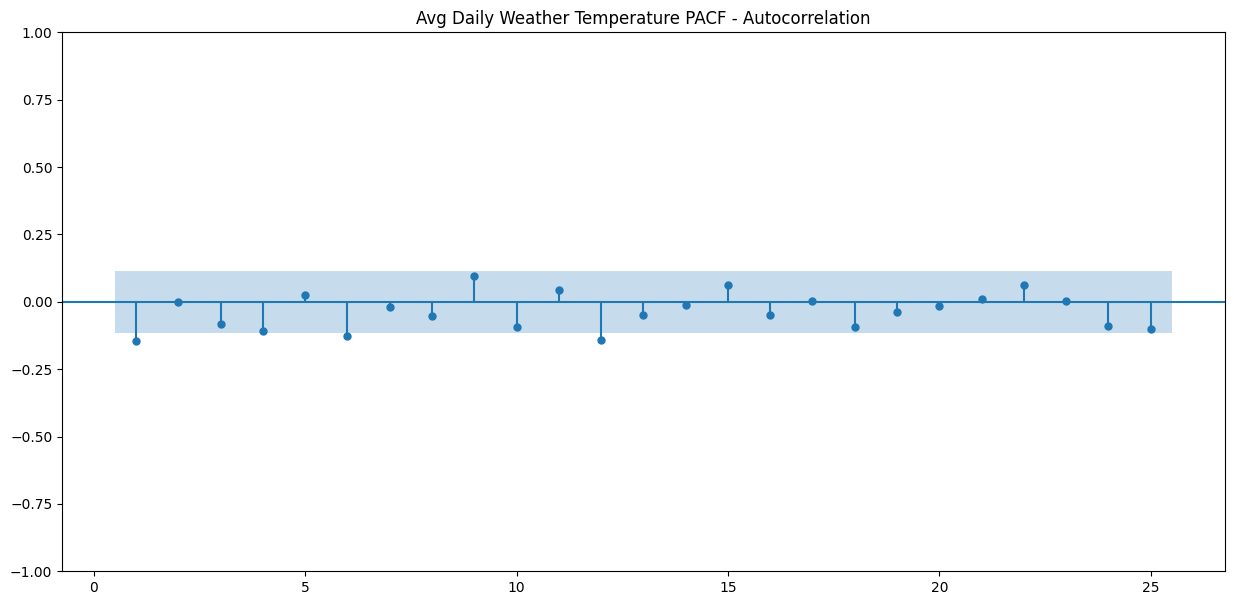

In [79]:
cols = ['yhat', 'resid', 'actual', 'Model Name']
plot_results(cols, dw_results, 'Avg Daily Weather Temperature')

The Hubber Regression model seems to perform well with a potential for further tuning.

------

The three regression models, ElasticNet, Lasso, and Ridge, add a regularization (penalization) term to the objective function that we want to minimize. In Lasso Regression, the regularization term can reduce the coefficient (the βs in the objective function) of the least important features (independent variables) to zero, and thus eliminating them. This added penalization term is called L1 regularization. In Ridge Regression, the regularization term is referred to as L2 regularization and can shrink the coefficients of the least important features but does not eliminate them (no zero coefficients). ElasticNet Regression, on the other hand, is a hybrid between the two by combining L1 and L2 regularization terms.

Regularization helps avoid overfitting during training and allows the model to better generalize. Additionally, L1 regularization can be used for feature selection.

You can inspect the coefficients to observe the effects, as shown in the following code block:

In [80]:
cols = ['Model Name', 'Model']
dw_models = dw_results.iloc[0:4][cols]

for row in dw_models.iterrows():
    print(row[1][0])
    print(row[1][1].coef_)

Linear Regression
[ 0.11418451 -0.00425813 -0.05389719  0.00491696  0.01005715 -0.01252609
  0.04988974  0.0936404  -0.13320625 -0.04650147  0.06992444  0.01989264
  0.05829665  0.06045198 -0.01134572 -0.08837107  0.02821013 -0.14340857
  0.15734195  0.69532382]
Elastic Net
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.04090826 0.37771847]
Ridge Regression
[ 0.11415037 -0.00425759 -0.05384532  0.00491039  0.01002225 -0.01245406
  0.049887    0.09349044 -0.13308473 -0.04645395  0.06986255  0.01994405
  0.05830015  0.06039926 -0.01133124 -0.0883267   0.02808462 -0.14320007
  0.15741965  0.6950348 ]
Lasso Regression
[0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.2528971]


The average daily temperature data has 20 features. Observe how the Linear Regression model and Ridge Regression Model estimated higher coefficient values (weights) for the last two features. On the other hand, ElasticNet Regression model estimates 8 feature coefficients at zero, discarding them leaves the model with the last two coefficients and lastly, the Lasso Regression model estimates only the last coefficient i.e the 20th lag coefficient.

Recall that these features were engineered and represent lags or the past values of the dependent variable (y). The coefficients from the four models suggest that the 20th feature (or lag) is alone significant in making a future prediction.

In [85]:
# Let's examine this concept and see whether one feature is sufficient
dw_20 = dw_reg[['y', 'x_20']]
train_dw20, test_dw20 = split_data(dw_20, test_split=0.10)
scaler_dw20 = Standardize()
train_dw20_stnd, test_dw20_stnd = scaler_dw.fit_transform(train_dw20, test_dw20)
dw_20_results = train_different_models(train_dw20_stnd, test_dw20_stnd, regressors)
cols = ['Model Name', 'RMSE', 'MAPE', 'MASE']

dw_20_results = pd.DataFrame(dw_results)
dw_20_results[cols].sort_values('MASE')

training Linear Regression ...
training Elastic Net ...
training Ridge Regression ...
training Lasso Regression ...
training Huber Regression ...


,Model Name,RMSE,MAPE,MASE
4,Huber Regression,0.640476,1.147118,0.963036
0,Linear Regression,0.625494,1.157447,0.994556
2,Ridge Regression,0.625485,1.157272,0.994569
1,Elastic Net,0.739347,0.925889,1.302249
3,Lasso Regression,0.816070,0.919457,1.469965


### 3. Multi-step forecasting using linear regression models with sckit-learn

Multi-step forecasting is predicting numerous steps forward without the need of waitinf until the next day to observe a new value to feed to the model.

In this recipe, you will implement a Recursive forecasting strategy. This will help you gain an idea of what a multi-step forecasting is all about. This is useful when you want to forecast further into the future beyond the out-of-sample (test) data that you have at hand.

In [87]:
# Extract the model and the model's name. Recall that there are five trained models
models = dw_results[['Model Name','Model']]
models

,Model Name,Model
0,Linear Regression,LinearRegression()
1,Elastic Net,ElasticNet(alpha=0.5)
2,Ridge Regression,Ridge(alpha=0.5)
3,Lasso Regression,Lasso(alpha=0.5)
4,Huber Regression,HuberRegressor()


In [101]:
def multi_step_forecast(data, model, steps=20):
    '''
    This function handles multi-stwp forecasting 

    data: dataset for forecasting
    model: type of model
    steps: default is equal to 20
    '''
    forecast = []
    for i in range(steps):
        one_step_pred = model.predict(np.array(data).reshape(1, -1))[0]
        forecast.append(one_step_pred)
        _ = data.pop(0)
        data.append(one_step_pred)

    return np.array(forecast)

Capture the last row from test_dw_s DataFrame. This represents the last 20 observations. Recall that the DataFrame was created using a 20-period sliding window, and the last row represents observations.

In [98]:
dw_ms = test_dw_stnd.drop(columns = ['y']).iloc[-1].tolist()

Loop through the models and pass the dw_ms list, the model, and the number of future steps (for example, 20 future steps) to the multi_step_forecast function

In [103]:
frcst_dw = {}

for i in models.iterrows():
    pred = multi_step_forecast(dw_ms, steps=20, model=i[1]['Model'])
    pred = scaler_dw.inverse_y(pred)
    frcst_dw[i[1]['Model Name']] = pred  

ValueError: X has 20 features, but LinearRegression is expecting 1 features as input.

In [107]:
for name, pred in frcst_dw.items():
    actual = dw_cp.iloc[-20:]
    ax = actual.plot(style='k-.')
    pd.Series(pred, index=dw_cp.index[-10:]).plot(style='k--o', ax=ax)
    plt.title(f'Multi-Step Forecasting with {name}')
    plt.legend(['actual', 'forecast'])
    plt.show()

In [108]:
def multiple_output(df, window_in, window_out):
    '''
    df:
    window_in:
    window_out:
    '''
    d = df.values
    n = len(df)
    idx = df.index[:-window_in]

    print(len(idx))

    x = []
    y = []
    for start in range(n-window_in):
        end = start + window_in
        out = end + window_out

        x.append(d[start:end].ravel())
        y.append(d[end:out].ravel())

    cols_x = [f'x_{i}' for i in range(1, window_in+1)]
    cols_y = [f'y_{i}' for i in range(1, window_out+1)]

    df_xs = pd.DataFrame(x, index=idx, columns=cols_x)
    df_y = pd.DataFrame(y, index=idx, columns=cols_y)

    return pd.concat([df_xs, df_y], axis=1).dropna()

In [109]:
win_in, win_out = 20, 20
dw_mo = multiple_output(dw_cp, win_in, win_out)
dw_mo.columns

2903


Index(['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10',
       'x_11', 'x_12', 'x_13', 'x_14', 'x_15', 'x_16', 'x_17', 'x_18', 'x_19',
       'x_20', 'y_1', 'y_2', 'y_3', 'y_4', 'y_5', 'y_6', 'y_7', 'y_8', 'y_9',
       'y_10', 'y_11', 'y_12', 'y_13', 'y_14', 'y_15', 'y_16', 'y_17', 'y_18',
       'y_19', 'y_20'],
      dtype='object')

In [110]:
train_dw, test_dw = split_data(dw_mo, test_split=0.10)
scaler_dw = Standardize()
train_dw_stnd, test_dw_stnd = scaler_dw.fit_transform(train_dw,test_dw)
X_train, y_train = train_dw_stnd.iloc[: , :win_in], train_dw_stnd.iloc[:, win_out:]
X_test, y_test = test_dw_stnd.iloc[: , :win_in], test_dw_stnd.iloc[:, win_out:]

In [111]:
lr = LinearRegression()
lr.fit(X_train, y_train)
mo_pred = lr.predict(X_test)[-1]

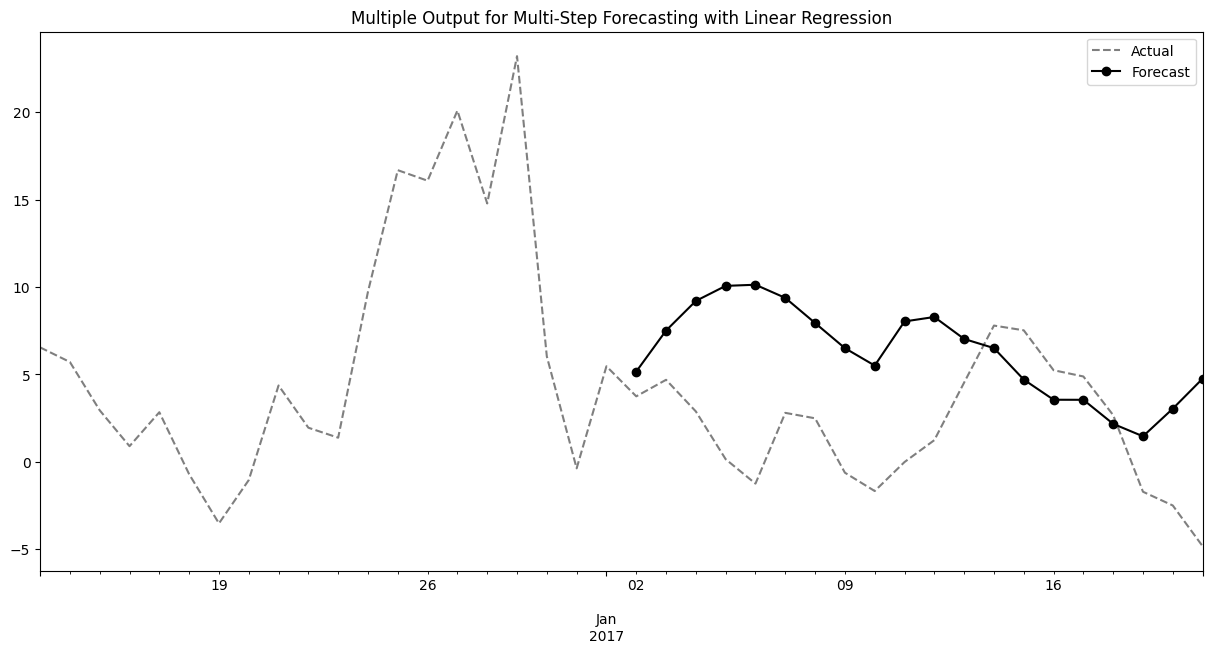

In [113]:
mo_pred = scaler_dw.inverse_y(lr.predict(X_test)[-1])
dates = pd.date_range('2016-12-13', freq='D', periods=40)
inputs, outputs = dates[:win_in], dates[win_out:]
pd.Series(test_dw.iloc[-1].values, index=dates).plot(style='k--', alpha=0.5)
pd.Series(mo_pred, index=outputs).plot(style='k-o')
plt.title('Multiple Output for Multi-Step Forecasting with Linear Regression')
plt.legend(['Actual', 'Forecast'])

### 4. Forecasting using non-linear models with sktime

In [116]:
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor)
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sktime.forecasting.all import (
    Deseasonalizer, Detrender,
    temporal_train_test_split,
    mean_absolute_percentage_error as mape,
    mean_squared_percentage_error as mspe,
    mean_squared_error as mse,
    ForecastingHorizon,
    NaiveForecaster,
    TransformedTargetForecaster,
    PolynomialTrendForecaster )
from sktime.forecasting.compose import make_reduction